# Background‑subtraction–based multi‑object tracking 

# Pipeline (generated by MS Copilot)

### 0) Input sequence & background model

*   You process a sequence of images as if they are frames of a video.
*   `cv2.createBackgroundSubtractorMOG2(...)` maintains a **statistical background model** over time (Mixture of Gaussians per pixel). Each new frame updates the model and yields a **foreground mask** (moving objects).

> ⚠️ Assumption: this works best with a **static camera** and temporally ordered frames. If the image list is shuffled or frames are far apart in time, MOG2 can struggle.

***

### 1) Foreground segmentation

```python
fg = bg.apply(frame)             # background subtraction → motion mask
fg = cv2.medianBlur(fg, 5)       # de-speckle salt-and-pepper
_, fg = cv2.threshold(fg, 200, 255, cv2.THRESH_BINARY)  # binarize confidently foreground
fg = cv2.morphologyEx(fg, cv2.MORPH_OPEN, kernel)       # remove small debris
```

*   **What this does:** Isolates **moving blobs** (candidate chickens) and cleans them up to reduce noise and small artifacts.

***

### 2) Contour extraction (proposals)

```python
contours, _ = cv2.findContours(fg, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
```

*   Finds **external contours** of white regions in the binary mask (each region = a candidate object).
*   You discard tiny contours: `if cv2.contourArea(cnt) < 500: continue`.

> We *use contours to define detections*, but the tracker itself is not a deformable contour model.

***

### 3) Color-based rejection (domain prior)

```python
if not is_color_valid(frame, mask, white_vs_straw="lab"):
    continue
```

*   Converts to **Lab** (or HSV) and measures **chroma** and yellow shift (`b` channel) inside the mask.
*   Heuristic: drop **straw‑colored** blobs; keep neutral/white/dark blobs likely to be chickens.

> Use of color space: **Lab** separates luminance (L) and chroma (a,b), making yellowish straw easier to reject.

***

### 4) Feature extraction per detection

```python
(cx, cy), hu, hist = extract_features(frame, mask)
```

*   **Centroid** from binary moments → rough position.
*   **Hu moments** (7 invariant shape descriptors), log‑scaled → shape.
*   **Color histogram** (BGR, 8×8×8 bins, normalized) → appearance.

This gives each detection a compact feature vector that’s **translation/scale/rotation robust** (Hu) and somewhat robust to lighting (color hist normalization).

***

### 5) Data association (frame‑to‑frame linking)

```python
# cost = weighted sum of distances
cost = centroid_dist + 10*hu_dist + 5*hist_bhattacharyya

row_ind, col_ind = linear_sum_assignment(cost)  # Hungarian algorithm
if cost[r, c] < 200: # gating
    update track r with detection c
else:
    mark track r missed
# unmatched detections start new tracks, missed tracks age out (missed >= 10 → dropped)
```

*   **Hungarian algorithm** gives a **globally optimal one‑to‑one matching** between existing tracks and current detections based on your cost.
*   The **gating threshold** (`< 200`) prevents bad matches; unmatched detections create **new tracks**; tracks without matches **increment `missed`** and are eventually **pruned**.

> This is canonical **tracking-by-detection** data association.

***

### 6) Output

*   **Masks** are saved per track and frame.
*   Optional visualization.

***


**The 'method' could be called:**

*   **Segmentation‑based multi‑object tracking (MOT)**.
*   **Background‑subtraction MOT with Hungarian data association**.
*   **Tracking‑by‑detection with contour‑derived proposals and appearance features**.

***

## What the distance terms do (intuition)

*   **Centroid distance**: favors spatial proximity (nearby in consecutive frames).
*   **Hu distance**: penalizes shape changes; helps keep identities if two chickens cross but retain different silhouettes.
*   **Bhattacharyya distance** on color histograms: penalizes appearance change; helps when shapes are similar but colors differ (e.g., dark vs white chickens).

The weighting `1 : 10 : 5` implicitly says **shape dominates**, then **color**, then **position**. That can be good if motion is erratic and shapes are distinctive; adjust if you see identity switches.

> Tip: these terms are in different **units/scales**. Consider **normalizing** each (e.g., by typical range/variance) so the weights have more consistent meaning.

***

## Strengths, assumptions, and typical failure modes

**Strengths**

*   Runs with **no training** (all classical CV).
*   Works well with **static cameras** and **moving subjects**.
*   Shape + color features are interpretable and fast.

**Assumptions**

*   **Static background/camera** or at least slowly changing background so MOG2 can learn it.
*   **Reasonable lighting**; shadows and highlights can affect the mask.

**Failure modes**

*   **ID switches** during **occlusion** or tight crossing (no motion model/Kalman makes this more likely).
*   **Background subtraction drift** if frames aren’t temporally continuous or the scene changes abruptly.
*   Straw and chickens with **similar color/texture** might pass/fail the heuristic incorrectly.
*   Fast motion or motion blur → centroid jumps → mis-assignments.

In [ ]:
from pathlib import Path
import os
import cv2
import numpy as np
from tqdm.auto import tqdm  # notebook-friendly tqdm
from scipy.optimize import linear_sum_assignment
from IPython.display import clear_output, display
import matplotlib.pyplot as plt

In [2]:
# -----------------------------------------------------------
# Utility functions
# -----------------------------------------------------------
def extract_features(frame, mask):
    """
    Compute:
      - centroid (cx, cy)
      - Hu moments (7 values)
      - color histogram (3-channel histogram)
    """

    # --- Centroid ---
    M = cv2.moments(mask, binaryImage=True)
    if M["m00"] > 0:
        cx = int(M["m10"] / M["m00"])
        cy = int(M["m01"] / M["m00"])
    else:
        cx, cy = 0, 0

    # --- Hu moments ---
    hu = cv2.HuMoments(M).flatten()
    # Optional for better numeric range:
    hu = -np.sign(hu) * np.log10(np.abs(hu) + 1e-12)

    # --- Color histogram (3-channel, 8 bins each) ---
    hist = cv2.calcHist(
        [frame],  # image
        [0, 1, 2],  # channels B,G,R
        mask,  # use only object pixels
        [8, 8, 8],  # histogram binning
        [0, 256, 0, 256, 0, 256],
    ).flatten()

    hist = cv2.normalize(hist, hist).flatten()

    return (cx, cy), hu, hist


def object_distance(features1, features2):
    """Weighted distance for assignment."""
    (c1, hu1, h1) = features1
    (c2, hu2, h2) = features2

    centroid_dist = np.linalg.norm(np.array(c1) - np.array(c2))
    hu_dist = np.linalg.norm(hu1 - hu2)
    hist_dist = cv2.compareHist(
        h1.astype(np.float32), h2.astype(np.float32), cv2.HISTCMP_BHATTACHARYYA
    )

    # Tune weights depending on your animals
    return 1.0 * centroid_dist + 10.0 * hu_dist + 5.0 * hist_dist


def is_color_valid(frame_bgr, mask, white_vs_straw="lab"):
    """
    Return True if the masked region looks like a chicken (white/neutral or dark),
    False if it looks like straw (yellowish, higher saturation).
    """
    # Ensure mask is binary 0/255
    if mask.dtype != np.uint8:
        mask = mask.astype(np.uint8)
    mask_bin = (mask > 0).astype(np.uint8)

    if white_vs_straw == "lab":
        lab = cv2.cvtColor(frame_bgr, cv2.COLOR_BGR2Lab)
        L, a, b = cv2.split(lab)
        # Only pixels inside the mask
        m = mask_bin.astype(bool)
        if m.sum() == 0:
            return False
        mean_L = float(L[m].mean())
        mean_a = float(a[m].mean())
        mean_b = float(b[m].mean())

        # Heuristic:
        # - Straw tends to have higher b (yellow) and moderate saturation (|a-128|, |b-128|)
        # - White chickens: low chroma (a,b ~ 128), can be bright L, or dark (black chicken: low L)
        chroma = np.hypot(mean_a - 128.0, mean_b - 128.0)

        # Tune thresholds on a short clip (print and inspect)
        # Reject if too yellowish (b >> 128) and chroma high:
        too_yellow = (mean_b - 128.0) > 12.0 and chroma > 14.0

        # Accept if clearly non-yellow OR very low chroma (near white/black)
        accept = (not too_yellow) or (chroma < 10.0)

        return bool(accept)

    else:  # HSV variant
        hsv = cv2.cvtColor(frame_bgr, cv2.COLOR_BGR2HSV)
        H, S, V = cv2.split(hsv)
        m = mask_bin.astype(bool)
        if m.sum() == 0:
            return False
        mean_S = float(S[m].mean())
        # White chickens → low S; straw → higher S (yellowish)
        return mean_S < 60.0  # tune empirically


# -----------------------------------------------------------
# Track class
# -----------------------------------------------------------


class Track:
    """Stores state of a tracked object."""

    next_id = 0

    def __init__(self, features, mask):
        self.id = Track.next_id
        Track.next_id += 1

        self.features = features
        self.mask = mask
        self.missed = 0  # frames since last detection

In [4]:
image_paths = sorted(Path("../data/test-img/").glob("*.jpg"))  # keep order stable
out_dir_path = "../sandbox/contour-tracking/masks"  # (typo fix: contour)
SAVE_MASKS = True

bg = cv2.createBackgroundSubtractorMOG2(history=500, varThreshold=120)

tracks = []
frame_idx = 0

if SAVE_MASKS:
    os.makedirs(out_dir_path, exist_ok=True)

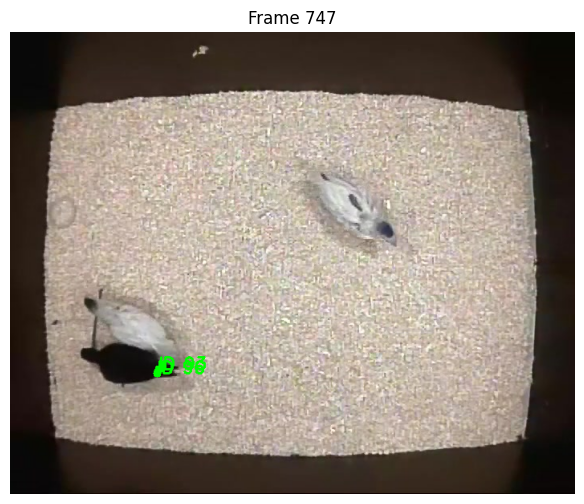

In [ ]:
# -----------------------------------------------------------
# Main processing
# -----------------------------------------------------------

for image in tqdm(image_paths, desc="Processing frames"):
    # Read still image safely
    frame = cv2.imread(str(image))
    if frame is None:
        continue

    # -------------------------------
    # Step 1 — segmentation
    # -------------------------------
    fg = bg.apply(frame)
    fg = cv2.medianBlur(fg, 5)
    _, fg = cv2.threshold(fg, 200, 255, cv2.THRESH_BINARY)

    kernel = np.ones((5, 5), np.uint8)
    fg = cv2.morphologyEx(fg, cv2.MORPH_OPEN, kernel)

    contours, _ = cv2.findContours(fg, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

    detected = []  # list of (features, mask)

    for cnt in contours:
        if cv2.contourArea(cnt) < 500:
            continue

        mask = np.zeros(frame.shape[:2], dtype=np.uint8)
        cv2.drawContours(mask, [cnt], -1, 255, -1)

        # Reject straw-like blobs
        if not is_color_valid(frame, mask, white_vs_straw="lab"):
            continue

        features = extract_features(frame, mask)
        detected.append((features, mask))

    # -------------------------------
    # Step 2 — Data Association
    # -------------------------------
    if len(tracks) == 0:
        for features, mask in detected:
            tracks.append(Track(features, mask))
    else:
        if len(detected) > 0 and len(tracks) > 0:
            cost = np.zeros((len(tracks), len(detected)), dtype=float)
            for i, tr in enumerate(tracks):
                for j, (f, m) in enumerate(detected):
                    cost[i, j] = object_distance(tr.features, f)

            row_ind, col_ind = linear_sum_assignment(cost)

            assigned_tracks = set()
            assigned_dets = set()

            for r, c in zip(row_ind, col_ind):
                if cost[r, c] < 200:
                    tracks[r].features = detected[c][0]
                    tracks[r].mask = detected[c][1]
                    tracks[r].missed = 0
                    assigned_tracks.add(r)
                    assigned_dets.add(c)

            for i, tr in enumerate(tracks):
                if i not in assigned_tracks:
                    tr.missed += 1

            tracks = [t for t in tracks if t.missed < 10]

            for j, (f, m) in enumerate(detected):
                if j not in assigned_dets:
                    tracks.append(Track(f, m))
        else:
            # No detections: mark misses and prune
            for tr in tracks:
                tr.missed += 1
            tracks = [t for t in tracks if t.missed < 10]

    # -------------------------------
    # Step 3 — Save masks
    # -------------------------------
    if SAVE_MASKS:
        for tr in tracks:
            filename = os.path.join(
                out_dir_path, f"frame_{frame_idx:05d}_ID_{tr.id}.png"
            )
            cv2.imwrite(filename, tr.mask)

    # -------------------------------
    # Step 4 — visualization (headless-safe)
    # -------------------------------
    vis = frame.copy()
    for tr in tracks:
        cx, cy = tr.features[0]
        cv2.putText(
            vis, f"ID {tr.id}", (cx, cy), cv2.FONT_HERSHEY_SIMPLEX, 0.7, (0, 255, 0), 2
        )
        cv2.circle(vis, (cx, cy), 5, (0, 255, 0), -1)

    # Show in notebook instead of cv2.imshow
    vis_rgb = cv2.cvtColor(vis, cv2.COLOR_BGR2RGB)
    plt.figure(figsize=(8, 6))
    plt.imshow(vis_rgb)
    plt.title(f"Frame {frame_idx}")
    plt.axis("off")
    display(plt.gcf())
    plt.close()
    clear_output(wait=True)

    frame_idx += 1

# No cv2.destroyAllWindows() needed when not creating native windows


**Comments:** In our case, the subject background similarity for white chickens results in a lot of false positives, and failure to track. 

*However*, tracking of the black chicken, which has quite high contrast with background works *surprisingly* well. 

In [5]:
output_masks = sorted(Path(out_dir_path).glob("*.png"))
output_masks[0:5]

[PosixPath('../sandbox/contour-tracking/masks/frame_00027_ID_0.png'),
 PosixPath('../sandbox/contour-tracking/masks/frame_00027_ID_1.png'),
 PosixPath('../sandbox/contour-tracking/masks/frame_00028_ID_0.png'),
 PosixPath('../sandbox/contour-tracking/masks/frame_00028_ID_1.png'),
 PosixPath('../sandbox/contour-tracking/masks/frame_00028_ID_2.png')]

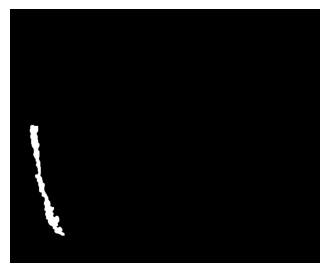

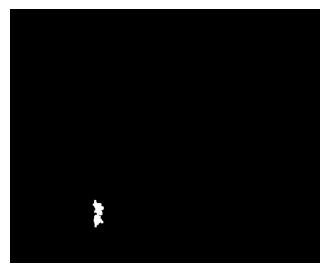

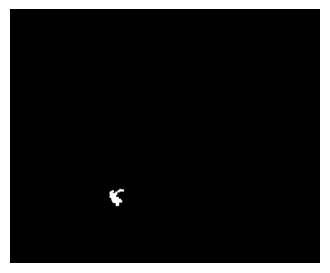

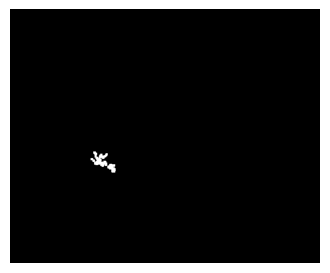

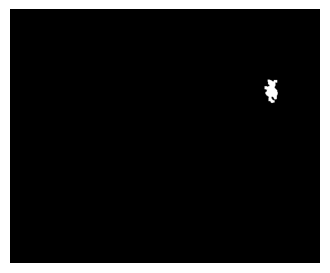

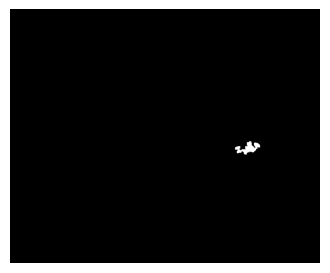

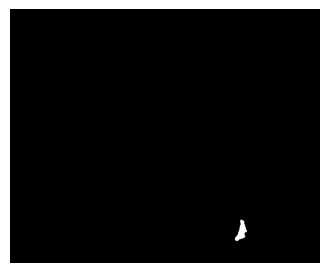

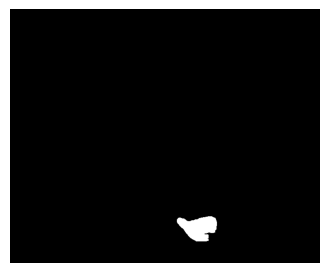

In [ ]:
for i in range(0, 700 + 1, 100):
    img = cv2.imread(str(output_masks[i]))
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    plt.figure(figsize=(4, 4))
    plt.imshow(img)
    plt.axis("off")